In [ ]:
import sys
sys.path.append('..')
from common_helper_functions import *

In [ ]:
path = "../../../../../../../../../../s/project/yeast_gxg/data/orthrus_data/"
rna_hl_human = np.load( path + 'rna_hl_human.npz')

In [3]:
investigate_dataset(rna_hl_human)

['X', 'y', 'genes']

Array shapes:
X shape: (12968, 12288, 6)
y shape: (12968,)
genes shape: (12968,)

First few y values: [ 0.6894531 -0.7753906  0.8334961  1.5537109 -2.1582031]

X dimensions: 3
X first sample shape: (12288, 6)
X first sample, first feature vector: [0. 1. 0. 0. 0.]


In [4]:
pca_embeddings, pca_model = isoform_to_gene_embeddings_pca(rna_hl_human['X'], rna_hl_human['genes'], n_components=2048)
print(f"PCA embeddings shape: {pca_embeddings.shape}")

PCA embeddings shape: (12968, 2048)


In [5]:
total_explained_variance = np.sum(pca_model.explained_variance_ratio_)
print(f"Total explained variance by PCA {total_explained_variance:.2%}")

Total explained variance by PCA 59.75%


In [6]:
pca_embeddings = create_gene_embedding_dataframe(pca_embeddings, rna_hl_human['genes'], method_name="mrl_pca")
pca_embeddings

,PCA_0,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,PCA_8,PCA_9,...,PCA_2038,PCA_2039,PCA_2040,PCA_2041,PCA_2042,PCA_2043,PCA_2044,PCA_2045,PCA_2046,PCA_2047
gene_id,,,,,,,,,,,,,,,,,,,,,
M6PR,-8.237803,-1.800538,9.178805,2.385733,2.096793,0.131338,4.832489,-6.338748,2.323429,0.591550,...,-0.726682,-0.019873,-0.121071,0.057837,0.357828,0.381511,0.889488,0.468197,0.053994,0.532348
CAMKK1,-2.776537,-2.950088,15.923879,7.525384,2.525625,-0.079276,8.388868,-3.421754,-0.973087,-5.601430,...,0.530635,0.616770,-0.431426,-0.190807,0.084185,-0.013453,-0.509744,0.445595,-0.676389,0.056007
RECQL,0.973829,-3.971321,17.951176,9.836235,1.754865,-0.029558,-1.073695,-5.399287,-4.254473,5.010963,...,0.219723,0.170246,-0.431566,0.308120,0.118163,-1.135644,-0.621083,-0.935865,0.573410,0.008355
SLC25A5,-14.954946,-6.669083,-6.679591,-8.113312,-5.334828,6.026587,-3.364748,2.998363,-2.957493,0.411875,...,0.111947,-0.114749,-0.608154,-0.034339,0.029180,0.006355,-0.133089,0.627648,0.278926,0.674489
HOXA11,-10.878604,9.096799,-3.440949,-2.067755,3.795646,-5.674979,-4.199227,-0.670099,3.291579,-0.987007,...,-0.226708,1.009757,0.230907,0.760276,-0.185875,0.372843,-0.785543,-0.074387,-1.534466,-0.737184
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CCL4,-15.734599,-0.233593,2.474267,-9.345885,-6.181315,-1.417677,2.460466,3.264155,-5.534058,-0.218945,...,-0.260852,0.434838,0.049491,-0.098665,0.512696,-0.590600,-0.301815,0.282905,0.076461,0.265262
TUBGCP5,2.122149,-18.301792,-15.866928,9.272836,4.941858,-1.461299,1.816455,-0.377388,-4.907519,5.436575,...,-0.799969,0.500770,-1.143148,-0.657197,0.013255,1.400991,0.257500,-0.179828,0.790225,-0.144438
UHRF1,3.821119,-17.756458,-14.319796,10.505579,3.448341,2.316536,0.060994,2.354964,-3.479996,-3.825353,...,0.478170,-0.757794,0.942721,-0.685227,0.245411,0.334983,0.370498,-0.802033,0.864549,0.117595


In [7]:
emogi_predictions = pd.read_csv('../../../../../../../../s/project/gene_embedding/input_data/cancer_eval/emogi_predictions.tsv', sep='\t')
emogi_predictions

,ID,Name,label,Prob_pos_1,Prob_pos_2,Prob_pos_3,Prob_pos_4,Prob_pos_5,Prob_pos_6,Prob_pos_7,...,Prob_pos_9,Prob_pos_10,Num_Pos,Mean_Pred,Std_Pred,NCG_Known_Cancer_Gene,NCG_Candidate_Cancer_Gene,OncoKB_Cancer_Gene,Bailey_et_al_Cancer_Gene,ONGene_Oncogene
0,ENSG00000100393,EP300,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,False
1,ENSG00000133703,KRAS,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,True
2,ENSG00000155657,TTN,False,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,False,True,False,False,False
3,ENSG00000284792,PTEN,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,False
4,ENSG00000039068,CDH1,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13622,ENSG00000266200,PNLIPRP2,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False
13623,ENSG00000125375,DMAC2L,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False
13624,ENSG00000173662,TAS1R1,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False
13625,ENSG00000197084,LCE1C,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False


In [8]:
pca_embeddings

,PCA_0,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,PCA_8,PCA_9,...,PCA_2038,PCA_2039,PCA_2040,PCA_2041,PCA_2042,PCA_2043,PCA_2044,PCA_2045,PCA_2046,PCA_2047
gene_id,,,,,,,,,,,,,,,,,,,,,
M6PR,-8.237803,-1.800538,9.178805,2.385733,2.096793,0.131338,4.832489,-6.338748,2.323429,0.591550,...,-0.726682,-0.019873,-0.121071,0.057837,0.357828,0.381511,0.889488,0.468197,0.053994,0.532348
CAMKK1,-2.776537,-2.950088,15.923879,7.525384,2.525625,-0.079276,8.388868,-3.421754,-0.973087,-5.601430,...,0.530635,0.616770,-0.431426,-0.190807,0.084185,-0.013453,-0.509744,0.445595,-0.676389,0.056007
RECQL,0.973829,-3.971321,17.951176,9.836235,1.754865,-0.029558,-1.073695,-5.399287,-4.254473,5.010963,...,0.219723,0.170246,-0.431566,0.308120,0.118163,-1.135644,-0.621083,-0.935865,0.573410,0.008355
SLC25A5,-14.954946,-6.669083,-6.679591,-8.113312,-5.334828,6.026587,-3.364748,2.998363,-2.957493,0.411875,...,0.111947,-0.114749,-0.608154,-0.034339,0.029180,0.006355,-0.133089,0.627648,0.278926,0.674489
HOXA11,-10.878604,9.096799,-3.440949,-2.067755,3.795646,-5.674979,-4.199227,-0.670099,3.291579,-0.987007,...,-0.226708,1.009757,0.230907,0.760276,-0.185875,0.372843,-0.785543,-0.074387,-1.534466,-0.737184
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CCL4,-15.734599,-0.233593,2.474267,-9.345885,-6.181315,-1.417677,2.460466,3.264155,-5.534058,-0.218945,...,-0.260852,0.434838,0.049491,-0.098665,0.512696,-0.590600,-0.301815,0.282905,0.076461,0.265262
TUBGCP5,2.122149,-18.301792,-15.866928,9.272836,4.941858,-1.461299,1.816455,-0.377388,-4.907519,5.436575,...,-0.799969,0.500770,-1.143148,-0.657197,0.013255,1.400991,0.257500,-0.179828,0.790225,-0.144438
UHRF1,3.821119,-17.756458,-14.319796,10.505579,3.448341,2.316536,0.060994,2.354964,-3.479996,-3.825353,...,0.478170,-0.757794,0.942721,-0.685227,0.245411,0.334983,0.370498,-0.802033,0.864549,0.117595


In [9]:
NCG_Known_Genes = emogi_predictions[['Name', "NCG_Known_Cancer_Gene", "NCG_Candidate_Cancer_Gene", "OncoKB_Cancer_Gene", "Bailey_et_al_Cancer_Gene"]]
merged = pca_embeddings.merge(NCG_Known_Genes, left_index=True, right_on='Name', how='inner')
merged.set_index('Name', inplace=True)
merged

,PCA_0,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,PCA_8,PCA_9,...,PCA_2042,PCA_2043,PCA_2044,PCA_2045,PCA_2046,PCA_2047,NCG_Known_Cancer_Gene,NCG_Candidate_Cancer_Gene,OncoKB_Cancer_Gene,Bailey_et_al_Cancer_Gene
Name,,,,,,,,,,,,,,,,,,,,,
M6PR,-8.237803,-1.800538,9.178805,2.385733,2.096793,0.131338,4.832489,-6.338748,2.323429,0.591550,...,0.357828,0.381511,0.889488,0.468197,0.053994,0.532348,False,False,False,False
CAMKK1,-2.776537,-2.950088,15.923879,7.525384,2.525625,-0.079276,8.388868,-3.421754,-0.973087,-5.601430,...,0.084185,-0.013453,-0.509744,0.445595,-0.676389,0.056007,False,False,False,False
RECQL,0.973829,-3.971321,17.951176,9.836235,1.754865,-0.029558,-1.073695,-5.399287,-4.254473,5.010963,...,0.118163,-1.135644,-0.621083,-0.935865,0.573410,0.008355,False,False,True,False
SLC25A5,-14.954946,-6.669083,-6.679591,-8.113312,-5.334828,6.026587,-3.364748,2.998363,-2.957493,0.411875,...,0.029180,0.006355,-0.133089,0.627648,0.278926,0.674489,False,False,False,False
HOXA11,-10.878604,9.096799,-3.440949,-2.067755,3.795646,-5.674979,-4.199227,-0.670099,3.291579,-0.987007,...,-0.185875,0.372843,-0.785543,-0.074387,-1.534466,-0.737184,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CCL4,-15.734599,-0.233593,2.474267,-9.345885,-6.181315,-1.417677,2.460466,3.264155,-5.534058,-0.218945,...,0.512696,-0.590600,-0.301815,0.282905,0.076461,0.265262,False,False,False,False
TUBGCP5,2.122149,-18.301792,-15.866928,9.272836,4.941858,-1.461299,1.816455,-0.377388,-4.907519,5.436575,...,0.013255,1.400991,0.257500,-0.179828,0.790225,-0.144438,False,False,False,False
UHRF1,3.821119,-17.756458,-14.319796,10.505579,3.448341,2.316536,0.060994,2.354964,-3.479996,-3.825353,...,0.245411,0.334983,0.370498,-0.802033,0.864549,0.117595,False,False,False,False


## Predict NCG_Known_Cancer_Gene

In [10]:
merged['NCG_Known_Cancer_Gene'].value_counts()

NCG_Known_Cancer_Gene
False    9724
True      572
Name: count, dtype: int64

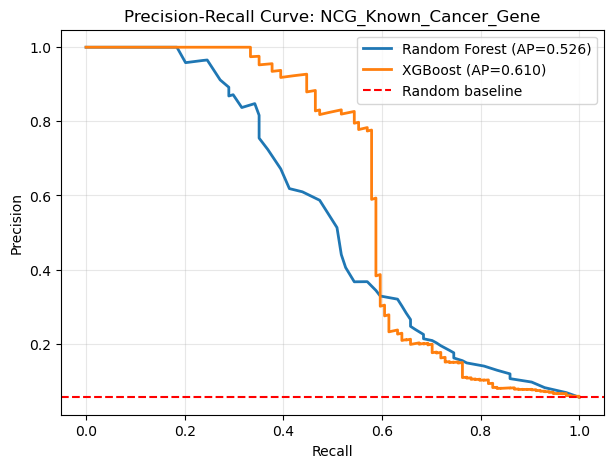

Random Forest - auPRC: 0.526
XGBoost - auPRC: 0.610



In [11]:
predict_and_plot_pr_curve(merged, 'NCG_Known_Cancer_Gene')

## NCG_Candidate_Cancer_Gene

In [12]:
merged['NCG_Candidate_Cancer_Gene'].value_counts()

NCG_Candidate_Cancer_Gene
False    9351
True      945
Name: count, dtype: int64

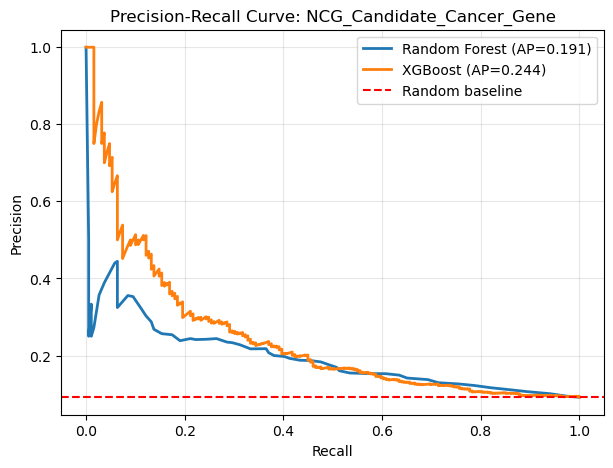

Random Forest - auPRC: 0.191
XGBoost - auPRC: 0.244



In [13]:
predict_and_plot_pr_curve(merged, 'NCG_Candidate_Cancer_Gene')

## OncoKB_Cancer_Gene

In [14]:
merged['OncoKB_Cancer_Gene'].value_counts()

OncoKB_Cancer_Gene
False    9831
True      465
Name: count, dtype: int64

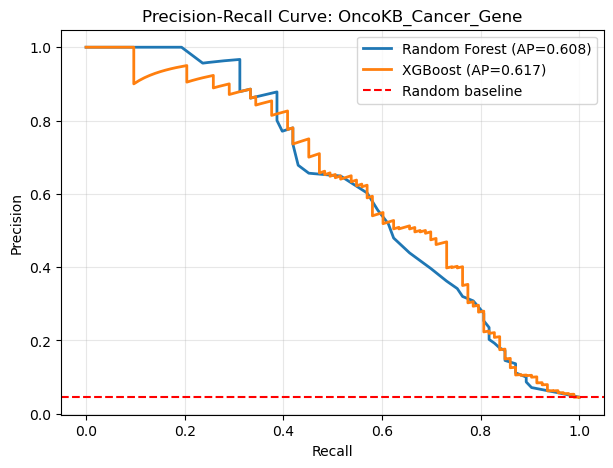

Random Forest - auPRC: 0.608
XGBoost - auPRC: 0.617



In [15]:
predict_and_plot_pr_curve(merged, 'OncoKB_Cancer_Gene')

## Bailey_et_al_Cancer_Gene

In [16]:
merged['Bailey_et_al_Cancer_Gene'].value_counts()

Bailey_et_al_Cancer_Gene
False    10050
True       246
Name: count, dtype: int64

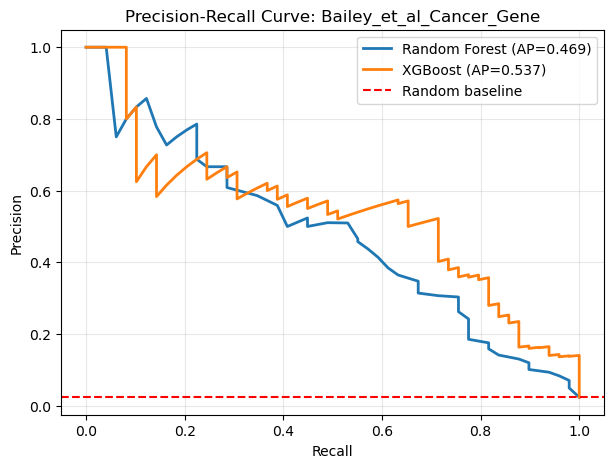

Random Forest - auPRC: 0.469
XGBoost - auPRC: 0.537



In [17]:
predict_and_plot_pr_curve(merged, 'Bailey_et_al_Cancer_Gene')